In [61]:
from umap import UMAP
from sklearn.manifold import TSNE, MDS

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from zadu.measures import (
    class_aware_trustworthiness_continuity,
    label_trustworthiness_and_continuity
)

In [24]:
dist_mat = np.load('dist_mat.npy')
labels = np.load('ship-types.npy')
original_data = np.load('original_data.npy')

In [25]:
original_data.shape

(750, 25, 10)

## MDS tyrimas

## t-SNE tyrimas

In [26]:
def plot_tsne(data, perplexity=0.1, early_exaggeration=100, ax=None):
    embeddings = TSNE(perplexity=perplexity, early_exaggeration=early_exaggeration)\
        .fit_transform(data)
    
    if ax is None:
        ax = plt.gca()

    print(embeddings[:, 0].shape, embeddings[:, 1].shape)
    sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], ax=ax, hue=labels) #, s=25, alpha=0.8, hue=labels, palette='bright', ax=ax)

In [27]:
from itertools import product

In [28]:
default_tsne_hyperparams = {
    "perplexity":         [5, 50, 200],
    "max_iter":             [250, 500, 2000],
    "early_exaggeration": [4.0, 12.0, 24.0],
    "learning_rate":      [10, 100, 1000],
}

keys = list(default_tsne_hyperparams.keys())
values = list(default_tsne_hyperparams.values())

In [29]:
results = []

for combo in product(*values):
    params = dict(zip(keys, combo))

    embedding = TSNE(
        perplexity         = params["perplexity"],
        max_iter           = params["max_iter"],
        early_exaggeration = params["early_exaggeration"],
        learning_rate      = params["learning_rate"],
        metric             = "precomputed",
        init               = "random",
        random_state       = 42,
    ).fit_transform(dist_mat)

    original_flat = original_data.reshape(len(original_data), -1)
    
    trust_score = 0
    cont_score = 0

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity\
            .measure(original_flat, embedding, label=labels, k=k)

        trust_score += ca_tc['ca_trustworthiness'] / 25
        cont_score += ca_tc['ca_continuity'] / 25

    results.append({
        **params,
        "ca_trustworhiness": trust_score,
        'ca_continuity': cont_score,
        "embedding": embedding
    })

In [30]:
results

[{'perplexity': 5,
  'max_iter': 250,
  'early_exaggeration': 4.0,
  'learning_rate': 10,
  'ca_trustworhiness': np.float64(0.9676890652585275),
  'ca_continuity': np.float64(0.9520483704078649),
  'embedding': array([[ 1.4736553 ,  2.466878  ],
         [ 3.3655944 , -0.99961257],
         [-6.204216  ,  2.8655882 ],
         ...,
         [-2.5933008 ,  7.091699  ],
         [ 3.151325  , -0.180715  ],
         [ 2.9546432 ,  8.465843  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 5,
  'max_iter': 250,
  'early_exaggeration': 4.0,
  'learning_rate': 100,
  'ca_trustworhiness': np.float64(0.9629305146348178),
  'ca_continuity': np.float64(0.9482022653610467),
  'embedding': array([[ 3.1113374,  2.416509 ],
         [ 3.8023539, -2.1057804],
         [-7.7807794,  2.5341308],
         ...,
         [-3.8948832,  6.8524585],
         [ 3.580851 , -1.2186129],
         [ 2.2040348,  9.624413 ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 5,
  'max_iter': 250,
  'early_exagge

In [31]:
def plot_tsne_param(param_name, param_values, distance_matrix, labels=None, random_state=42):
    n = len(param_values)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, val in enumerate(param_values):
        params = {param_name: val}

        max_iter = 1000 if param_name != 'max_iter' else val
        perplexity = 50 if param_name != 'perplexity' else val

        if param_name in ['max_iter', 'perplexity']:
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                max_iter=max_iter,
                perplexity=perplexity,
                init="random",
            )

        elif param_name == 'max_iter':
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                perplexity=perplexity,
                init="random",
                **params
            )

        elif param_name == 'perplexity':
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                max_iter=max_iter,
                init="random",
                **params
            )

        else:
            tsne = TSNE(
                n_components=2,
                metric="precomputed",
                random_state=random_state,
                init="random",
                **params
            )

        embedding = tsne.fit_transform(distance_matrix)

        ax = axes[i]
        original_flat = original_data.reshape(len(original_data), -1)
        
        trust_score = 0
        cont_score = 0

        for k in range(5, 30):
            ca_tc = class_aware_trustworthiness_continuity.measure(
                original_flat, embedding, label=labels, k=k
            )

            trust_score += ca_tc['ca_trustworthiness'] / 25
            cont_score += ca_tc['ca_continuity'] / 25


        # ---- compute these only once ----
        knn = KNeighborsClassifier(n_neighbors=5)
        knn_acc = cross_val_score(knn, embedding, labels, cv=5).mean()

        sil_score = silhouette_score(embedding, labels)
        ch_score = calinski_harabasz_score(embedding, labels)
        db_score = davies_bouldin_score(embedding, labels)

        print(
            "Value:", val,
            "CA Continuity", cont_score,
            "CA Trustworthiness", trust_score,
            "KNN", knn_acc,
            "Silhouette", sil_score,
            "Calinski-Harabasz", ch_score,
            "Davies-Bouldin", db_score
        )

        if labels is not None:
            sns.scatterplot(
                x=embedding[:, 0],
                y=embedding[:, 1],
                hue=labels,
                palette="tab10",
                ax=ax,
                legend=False
            )
        else:
            ax.scatter(embedding[:, 0], embedding[:, 1])

        ax.set_title(f"{param_name} = {val}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

Value: 5 CA Continuity 0.9817115916472144 CA Trustworthiness 0.9779886017805538 KNN 0.7733333333333332 Silhouette -0.03208116069436073 Calinski-Harabasz 48.183204650878906 Davies-Bouldin 4.758534673377697
Value: 50 CA Continuity 0.993423015048769 CA Trustworthiness 0.9906095571931899 KNN 0.7653333333333333 Silhouette -0.0350336879491806 Calinski-Harabasz 66.66670227050781 Davies-Bouldin 6.406397088717407
Value: 200 CA Continuity 0.9933904671472745 CA Trustworthiness 0.9863800565033997 KNN 0.6933333333333334 Silhouette -0.037414778023958206 Calinski-Harabasz 55.56061553955078 Davies-Bouldin 6.195683440127469


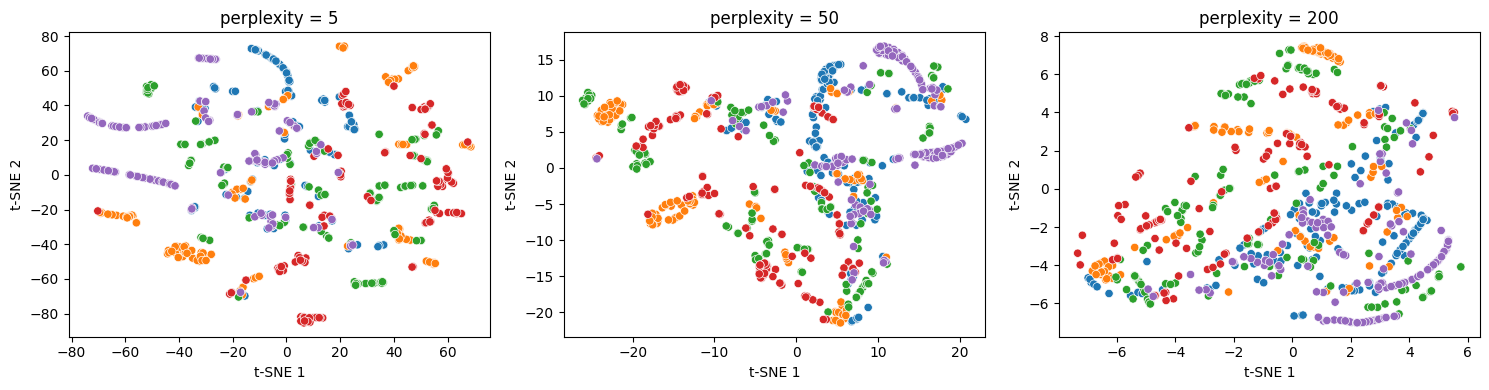

In [32]:
plot_tsne_param(
    param_name="perplexity",
    param_values=default_tsne_hyperparams['perplexity'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 250 CA Continuity 0.990234954275554 CA Trustworthiness 0.9510669317019134 KNN 0.6586666666666667 Silhouette -0.04679281637072563 Calinski-Harabasz 52.38292694091797 Davies-Bouldin 5.467739987345899
Value: 500 CA Continuity 0.9935084962966249 CA Trustworthiness 0.9891497282183983 KNN 0.76 Silhouette -0.03565762937068939 Calinski-Harabasz 67.56249237060547 Davies-Bouldin 6.831593608054052
Value: 2000 CA Continuity 0.9933657254787464 CA Trustworthiness 0.9908688569688823 KNN 0.764 Silhouette -0.03415343537926674 Calinski-Harabasz 67.43267059326172 Davies-Bouldin 6.255623008926323


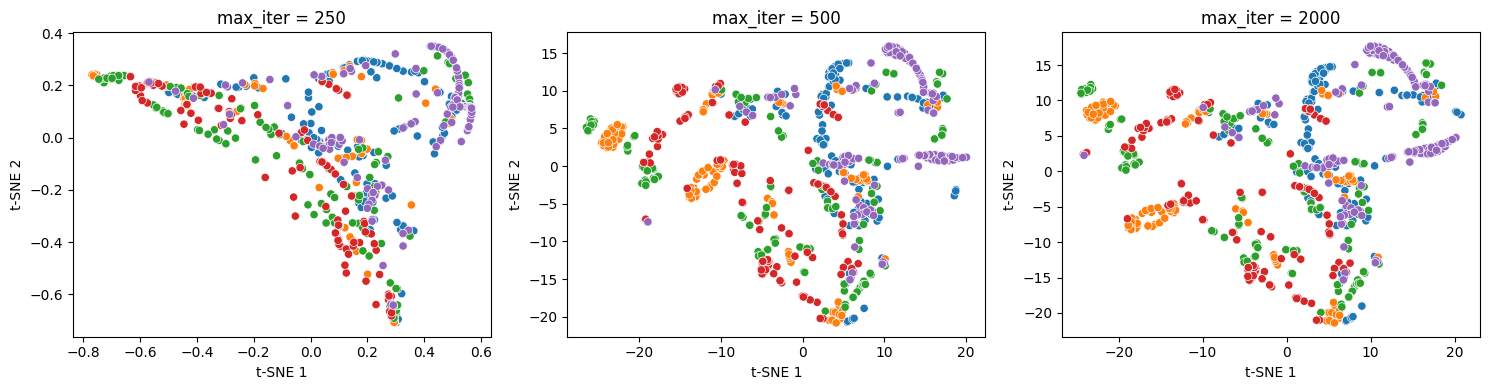

In [33]:
plot_tsne_param(
    param_name="max_iter",
    param_values=default_tsne_hyperparams['max_iter'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 4.0 CA Continuity 0.9912724320894418 CA Trustworthiness 0.9914735188796927 KNN 0.7626666666666667 Silhouette -0.03737296536564827 Calinski-Harabasz 30.226411819458008 Davies-Bouldin 11.2800895426957
Value: 12.0 CA Continuity 0.9931435281453386 CA Trustworthiness 0.9911542060486824 KNN 0.7506666666666666 Silhouette -0.024688392877578735 Calinski-Harabasz 78.90380859375 Davies-Bouldin 5.212017852259968
Value: 24.0 CA Continuity 0.9926877189365517 CA Trustworthiness 0.9922092653057124 KNN 0.7533333333333334 Silhouette -0.027010014280676842 Calinski-Harabasz 80.35562896728516 Davies-Bouldin 4.571817739539098


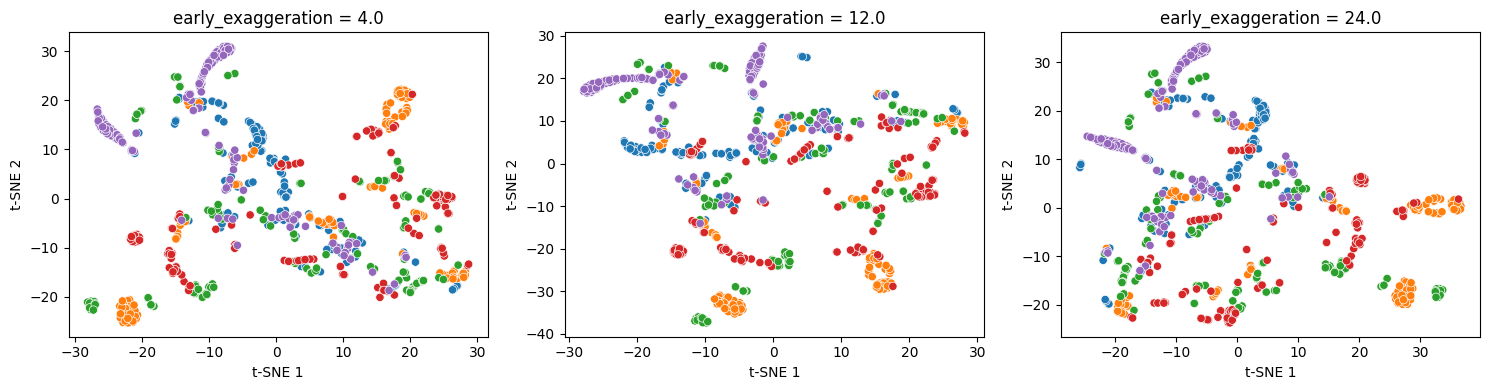

In [34]:
plot_tsne_param(
    param_name="early_exaggeration",
    param_values=default_tsne_hyperparams['early_exaggeration'],
    distance_matrix=dist_mat,
    labels=labels
)

Value: 10 CA Continuity 0.9931607803692731 CA Trustworthiness 0.9919398244968223 KNN 0.7613333333333333 Silhouette -0.029294008389115334 Calinski-Harabasz 67.77082061767578 Davies-Bouldin 4.53115615015207
Value: 100 CA Continuity 0.9932591450820241 CA Trustworthiness 0.9911376966925896 KNN 0.76 Silhouette -0.02997182495892048 Calinski-Harabasz 69.42121887207031 Davies-Bouldin 4.51408279746091
Value: 1000 CA Continuity 0.9926165148798285 CA Trustworthiness 0.9915215847260005 KNN 0.756 Silhouette -0.028455769643187523 Calinski-Harabasz 79.72705841064453 Davies-Bouldin 4.8020508686989745


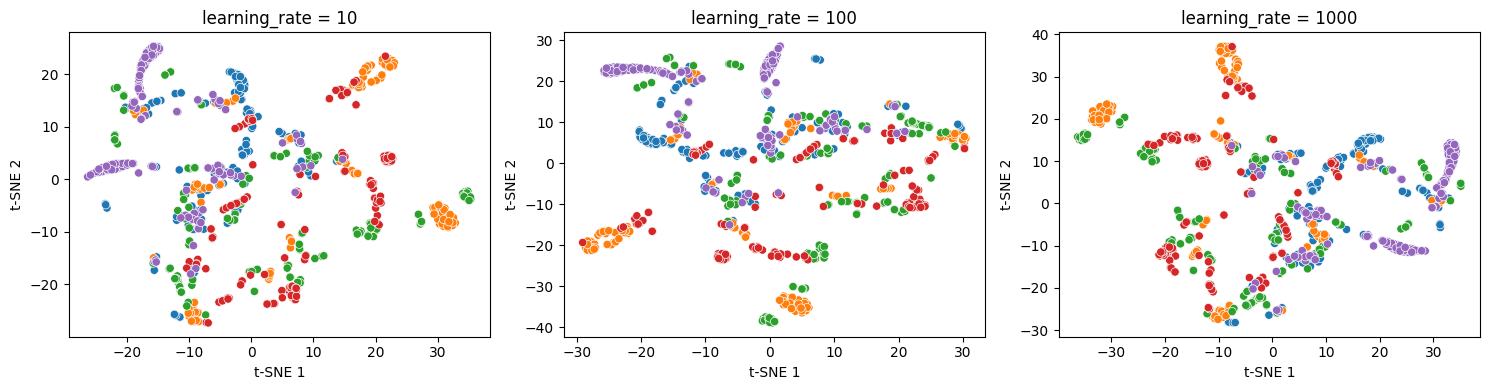

In [35]:
plot_tsne_param(
    param_name="learning_rate",
    param_values=default_tsne_hyperparams['learning_rate'],
    distance_matrix=dist_mat,
    labels=labels
)

In [36]:
sorted(results, key=lambda x: -1 * x['ca_continuity'])

[{'perplexity': 200,
  'max_iter': 500,
  'early_exaggeration': 4.0,
  'learning_rate': 1000,
  'ca_trustworhiness': np.float64(0.9874271478226054),
  'ca_continuity': np.float64(0.994260989720547),
  'embedding': array([[ 1.2861645 ,  7.357272  ],
         [-1.2355167 ,  2.7220254 ],
         [-0.06961117, -6.0035877 ],
         ...,
         [-4.213403  , -2.666049  ],
         [-0.2516192 ,  3.282312  ],
         [-5.455104  , -0.38184956]], shape=(750, 2), dtype=float32)},
 {'perplexity': 200,
  'max_iter': 2000,
  'early_exaggeration': 4.0,
  'learning_rate': 1000,
  'ca_trustworhiness': np.float64(0.9874324178039989),
  'ca_continuity': np.float64(0.994257404558853),
  'embedding': array([[ 1.3237807 ,  6.887771  ],
         [-1.1980858 ,  2.246211  ],
         [-0.03021801, -6.4816303 ],
         ...,
         [-4.169978  , -3.1463811 ],
         [-0.21616209,  2.807353  ],
         [-5.415261  , -0.8595012 ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 200,
  'max_iter': 

In [37]:
sorted(results, key=lambda x: -1 * x['ca_trustworhiness'])

[{'perplexity': 50,
  'max_iter': 2000,
  'early_exaggeration': 4.0,
  'learning_rate': 10,
  'ca_trustworhiness': np.float64(0.9922292231723278),
  'ca_continuity': np.float64(0.9930998078962779),
  'embedding': array([[17.874783  , -1.5572002 ],
         [ 9.385223  ,  4.557514  ],
         [-8.002812  , -0.89662623],
         ...,
         [-8.802393  , 17.12974   ],
         [10.003619  ,  2.459827  ],
         [-4.555776  , 21.06168   ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 50,
  'max_iter': 2000,
  'early_exaggeration': 24.0,
  'learning_rate': 100,
  'ca_trustworhiness': np.float64(0.9922276653546659),
  'ca_continuity': np.float64(0.989983732408405),
  'embedding': array([[ 18.025164  ,  11.914683  ],
         [-14.201089  ,   1.7445592 ],
         [  0.48957935,  -8.86511   ],
         ...,
         [ -5.649064  ,   8.969897  ],
         [-15.592284  ,   2.53824   ],
         [ -5.042726  ,  15.524524  ]], shape=(750, 2), dtype=float32)},
 {'perplexity': 50,
  'ma

## UMAP tyrimas

In [ ]:
def plot_umap(
    data,
    min_dist=0.01,
    n_neighbors=20,
    n_epochs=None,
    learning_rate=1.0,
    ax=None,
    var="min_dist"
):

    embedding = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_epochs=n_epochs,
        learning_rate=learning_rate,
        metric="precomputed",
        random_state=1
    ).fit_transform(data)

    if ax is None:
        ax = plt.gca()

    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=labels,
        palette="tab10",
        s=25,
        alpha=0.8,
        legend=False,
        ax=ax
    )

    ax.set_title(f"{var}={locals()[var]}")

    # ---------- trustworthiness metrics ----------
    original_flat = original_data.reshape(len(original_data), -1)

    trust_score = 0
    cont_score = 0

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_score += ca_tc["ca_trustworthiness"] / 25
        cont_score += ca_tc["ca_continuity"] / 25

    # ---------- KNN accuracy ----------
    knn = KNeighborsClassifier(n_neighbors=5)
    knn_acc = cross_val_score(knn, embedding, labels, cv=5).mean()

    # ---------- clustering metrics ----------
    sil_score = silhouette_score(embedding, labels)
    ch_score = calinski_harabasz_score(embedding, labels)
    db_score = davies_bouldin_score(embedding, labels)

    print(
        f"{var}={locals()[var]} | "
        f"CA Cont {cont_score:.4f} | "
        f"CA Trust {trust_score:.4f} | "
        f"KNN {knn_acc:.3f} | "
        f"Sil {sil_score:.3f} | "
        f"CH {ch_score:.1f} | "
        f"DB {db_score:.3f}"
    )

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.1 | CA Cont 0.9900 | CA Trust 0.9880 | KNN 0.667 | Sil -0.024 | CH 80.1 | DB 3.671


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.001 | CA Cont 0.9887 | CA Trust 0.9879 | KNN 0.668 | Sil -0.043 | CH 62.0 | DB 4.621


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=0.0001 | CA Cont 0.9881 | CA Trust 0.9883 | KNN 0.680 | Sil -0.033 | CH 64.2 | DB 4.129


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


min_dist=1e-05 | CA Cont 0.9869 | CA Trust 0.9879 | KNN 0.667 | Sil -0.062 | CH 61.2 | DB 4.202


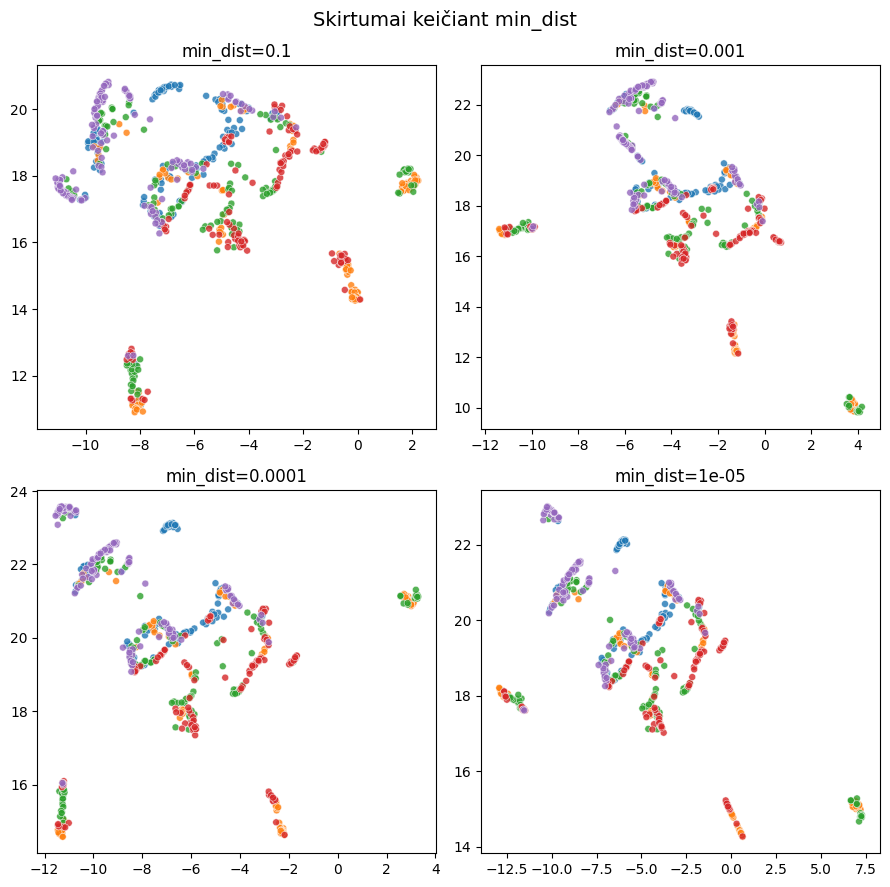

In [ ]:
min_distances = [0.1, 0.001, 0.0001, 0.00001]


fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

fig.suptitle('Skirtumai keičiant min_dist', fontsize=14)

for i, n in enumerate(min_distances):
    plot_umap(data=dist_mat, min_dist=n, ax=axs[i], var='min_dist')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


n_neighbors=5 | CA Cont 0.9486 | CA Trust 0.9575 | KNN 0.744 | Sil -0.065 | CH 35.4 | DB 4.898


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=10 | CA Cont 0.9814 | CA Trust 0.9886 | KNN 0.721 | Sil -0.069 | CH 56.6 | DB 3.985


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=20 | CA Cont 0.9887 | CA Trust 0.9879 | KNN 0.667 | Sil -0.030 | CH 79.1 | DB 3.789


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_neighbors=50 | CA Cont 0.9847 | CA Trust 0.9765 | KNN 0.652 | Sil -0.040 | CH 71.0 | DB 6.485


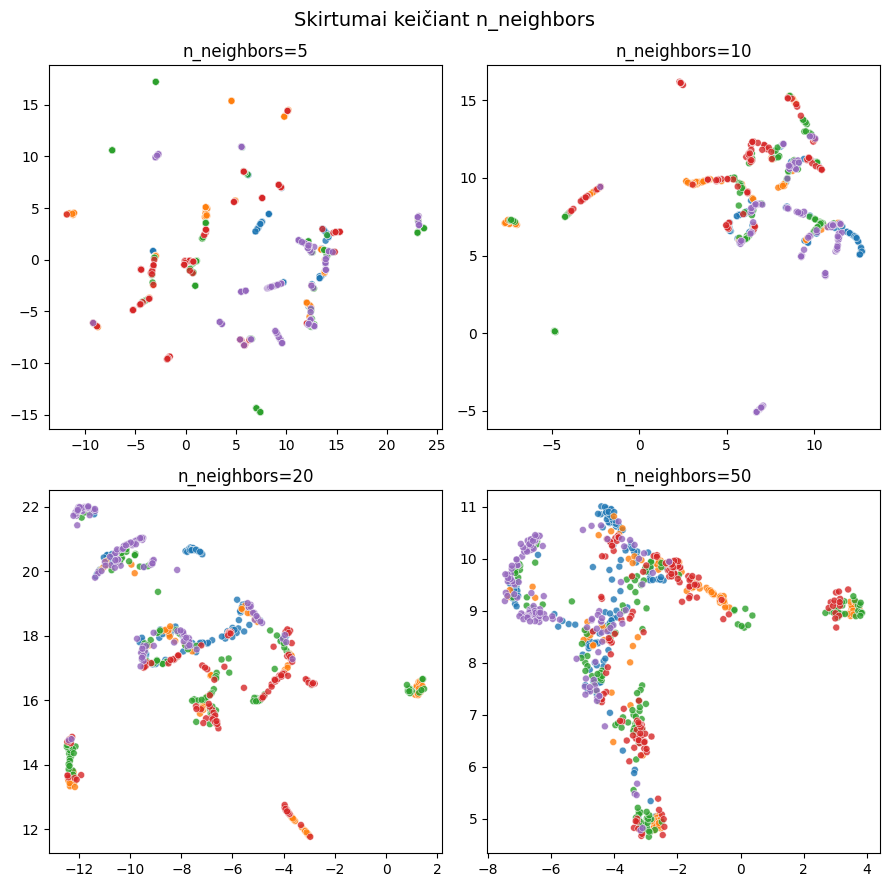

In [ ]:
neighbors = [5, 10, 20, 50]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

fig.suptitle('Skirtumai keičiant n_neighbors', fontsize=14)

for i, n in enumerate(neighbors):
    plot_umap(data=dist_mat, n_neighbors=n, ax=axs[i], var='n_neighbors')

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=25 | CA Cont 0.9878 | CA Trust 0.9833 | KNN 0.644 | Sil -0.030 | CH 55.3 | DB 5.759


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=50 | CA Cont 0.9895 | CA Trust 0.9856 | KNN 0.693 | Sil -0.038 | CH 53.5 | DB 4.281


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=100 | CA Cont 0.9896 | CA Trust 0.9857 | KNN 0.657 | Sil -0.043 | CH 55.2 | DB 4.538


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_epochs=300 | CA Cont 0.9887 | CA Trust 0.9882 | KNN 0.644 | Sil -0.037 | CH 64.9 | DB 4.264


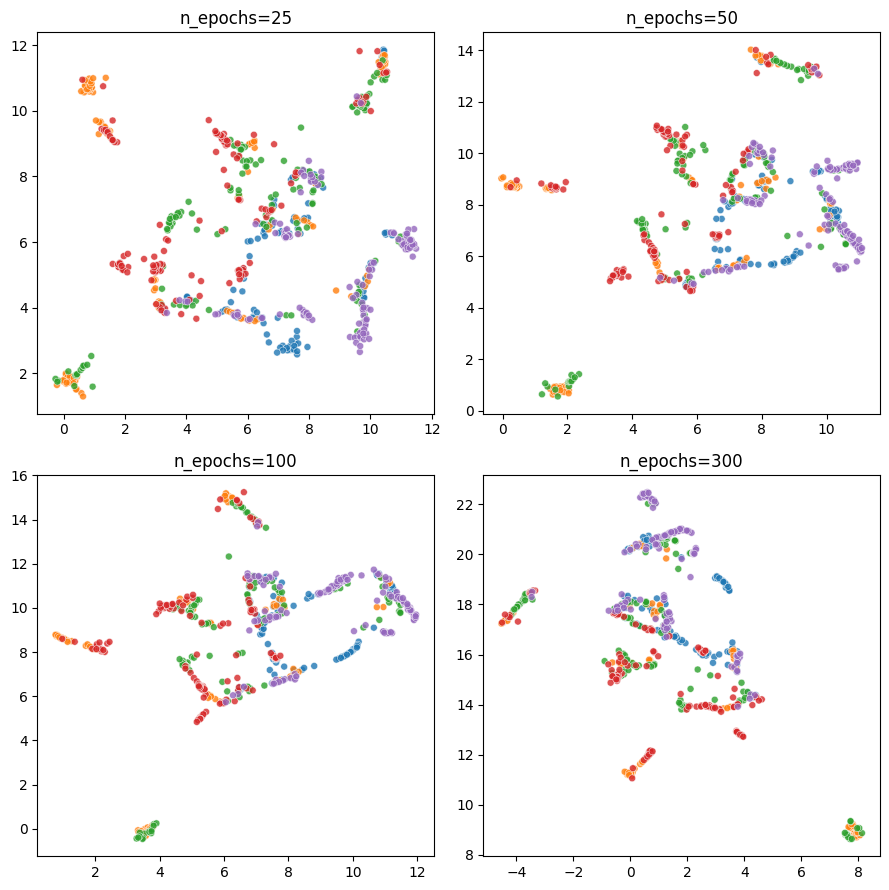

In [53]:
epochs = [25, 50, 100, 300]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

for i, e in enumerate(epochs):
    plot_umap(data=dist_mat, n_epochs=e, ax=axs[i], var="n_epochs")

plt.tight_layout()
plt.show()

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=1.0 | CA Cont 0.9887 | CA Trust 0.9879 | KNN 0.667 | Sil -0.030 | CH 79.1 | DB 3.789


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=5.0 | CA Cont 0.9893 | CA Trust 0.9864 | KNN 0.664 | Sil -0.038 | CH 61.4 | DB 4.841


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=10 | CA Cont 0.9894 | CA Trust 0.9855 | KNN 0.649 | Sil -0.044 | CH 65.7 | DB 4.259


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


learning_rate=15 | CA Cont 0.9874 | CA Trust 0.9835 | KNN 0.639 | Sil -0.039 | CH 71.7 | DB 4.343


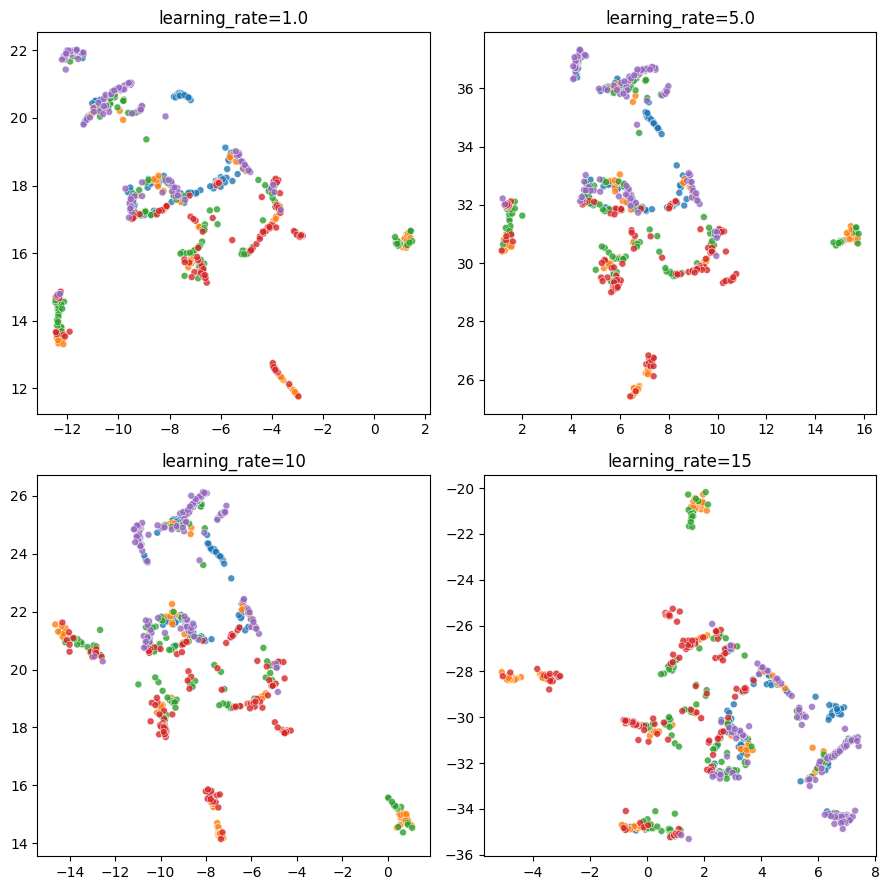

In [55]:
rates = [1.0, 5.0, 10, 15]

fig, axs = plt.subplots(2, 2, figsize=(9, 9))
axs = axs.flatten()

for i, r in enumerate(rates):
    plot_umap(data=dist_mat, learning_rate=r, ax=axs[i], var="learning_rate")

plt.tight_layout()
plt.show()

In [58]:
def search_umap_params(
    distance_matrix,
    labels,
    n_neighbors_list,
    min_dist_list,
    n_epochs_list,
    learning_rate_list,
    random_state=42
):

    results = []

    original_flat = original_data.reshape(len(original_data), -1)

    for nn in n_neighbors_list:
        for md in min_dist_list:
            for ne in n_epochs_list:
                for lr in learning_rate_list:

                    print(f"Testing: neighbors={nn}, min_dist={md}, epochs={ne}, lr={lr}")

                    umap_model = UMAP(
                        n_neighbors=nn,
                        min_dist=md,
                        n_epochs=ne,
                        learning_rate=lr,
                        metric="precomputed",
                        random_state=random_state
                    )

                    embedding = umap_model.fit_transform(distance_matrix)

                    # ----- CA Trustworthiness / Continuity -----
                    trust_score = 0
                    cont_score = 0

                    for k in range(5, 30):
                        ca_tc = class_aware_trustworthiness_continuity.measure(
                            original_flat,
                            embedding,
                            label=labels,
                            k=k
                        )

                        trust_score += ca_tc["ca_trustworthiness"] / 25
                        cont_score += ca_tc["ca_continuity"] / 25

                    # ----- KNN accuracy -----
                    knn = KNeighborsClassifier(n_neighbors=5)
                    knn_acc = cross_val_score(knn, embedding, labels, cv=5).mean()

                    # ----- clustering metrics -----
                    sil = silhouette_score(embedding, labels)
                    ch = calinski_harabasz_score(embedding, labels)
                    db = davies_bouldin_score(embedding, labels)

                    results.append({
                        "n_neighbors": nn,
                        "min_dist": md,
                        "n_epochs": ne,
                        "learning_rate": lr,
                        "ca_trustworthiness": trust_score,
                        "ca_continuity": cont_score,
                        "knn_accuracy": knn_acc,
                        "silhouette": sil,
                        "calinski_harabasz": ch,
                        "davies_bouldin": db
                    })

    df = pd.DataFrame(results)

    # ranking score (higher better, except DB)
    df["score"] = (
        df["knn_accuracy"]
        + df["silhouette"]
        + df["ca_trustworthiness"]
        + df["ca_continuity"]
        + (df["calinski_harabasz"] / df["calinski_harabasz"].max())
        - df["davies_bouldin"]
    )

    best = df.sort_values("score", ascending=False).iloc[0]

    return df, best

In [64]:
min_dists = [0.001, 0.01]
neighbors = [10, 20, 50]
epochs = [25, 50, 100]
rates = [1.0, 5.0, 10]

results_df, best_params = search_umap_params(
    dist_mat,
    labels,
    neighbors,
    min_dists,
    epochs,
    rates
)

print("\nBEST CONFIGURATION:")
print(best_params)

Testing: neighbors=10, min_dist=0.001, epochs=25, lr=1.0


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Testing: neighbors=10, min_dist=0.001, epochs=25, lr=5.0


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Testing: neighbors=10, min_dist=0.001, epochs=25, lr=10


...

Testing: neighbors=50, min_dist=0.01, epochs=100, lr=5.0


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Testing: neighbors=50, min_dist=0.01, epochs=100, lr=10


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



BEST CONFIGURATION:
n_neighbors            10.000000
min_dist                0.001000
n_epochs              100.000000
learning_rate          10.000000
ca_trustworthiness      0.976784
ca_continuity           0.982065
knn_accuracy            0.677333
silhouette             -0.054516
calinski_harabasz      74.603798
davies_bouldin          3.507688
score                   0.038953
Name: 8, dtype: float64


In [40]:
class_aware_trustworthiness_continuity.measure(
    
)

TypeError: measure() missing 3 required positional arguments: 'orig', 'emb', and 'label'